# Homework 3

## Question 1: MA($q$) Model and Bitcoin Returns

For an MA(2) process,

$$
X_t = \mu + \varepsilon_t + a_1\varepsilon_{t-1} + a_2\varepsilon_{t-2},
$$

where $\{\varepsilon_t\}$ is white noise with

$$
E(\varepsilon_t)=0, \qquad \operatorname{Var}(\varepsilon_t)=\sigma^2.
$$

Then

$$
E(X_t)=\mu,
$$

$$
\gamma(0)=\operatorname{Var}(X_t)=\sigma^2(1+a_1^2+a_2^2),
$$

$$
\gamma(1)=\sigma^2(a_1+a_1a_2), \qquad \gamma(2)=\sigma^2 a_2,
$$

and

$$
\gamma(h)=0 \quad \text{for } h>2.
$$

More generally, for an MA($q$) process, the theoretical ACF cuts off after lag $q$:

$$
\rho(h)=0 \quad \text{for } h>q.
$$

The code below uses Bitcoin price data to construct returns and examine whether the sample ACF is consistent with a finite-order MA($q$) pattern.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
df = pd.read_csv('bitcoin_data(2).csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

price_col = 'Adj Close' if 'Adj Close' in df.columns else 'Close'
df['Price'] = pd.to_numeric(df[price_col], errors='coerce')

df[['Date', 'Price']].head()

,Date,Price
0,2018-01-01,13657.200195
1,2018-01-02,14982.099609
2,2018-01-03,15201.000000
3,2018-01-04,15599.200195
4,2018-01-05,17429.500000


In [3]:
# Log returns
df['Return'] = np.log(df['Price']).diff()
returns = df['Return'].dropna().reset_index(drop=True)

returns.head()

0    0.092589
1    0.014505
2    0.025858
3    0.110945
4    0.005578
Name: Return, dtype: float64

Bitcoin prices are usually non-stationary, so the empirical check should be based on returns rather than raw prices. The log return is

$$
r_t = \log(P_t) - \log(P_{t-1}).
$$

If returns follow an MA($q$) model, then the sample ACF should be noticeably different from zero only for the first few lags and should become negligible after lag $q$.

In [4]:
summary = returns.describe().to_frame(name='Log Return')
summary

,Log Return
count,2555.000000
mean,0.000749
std,0.035673
min,-0.464730
25%,-0.013878
50%,0.000824
75%,0.016080
max,0.171821


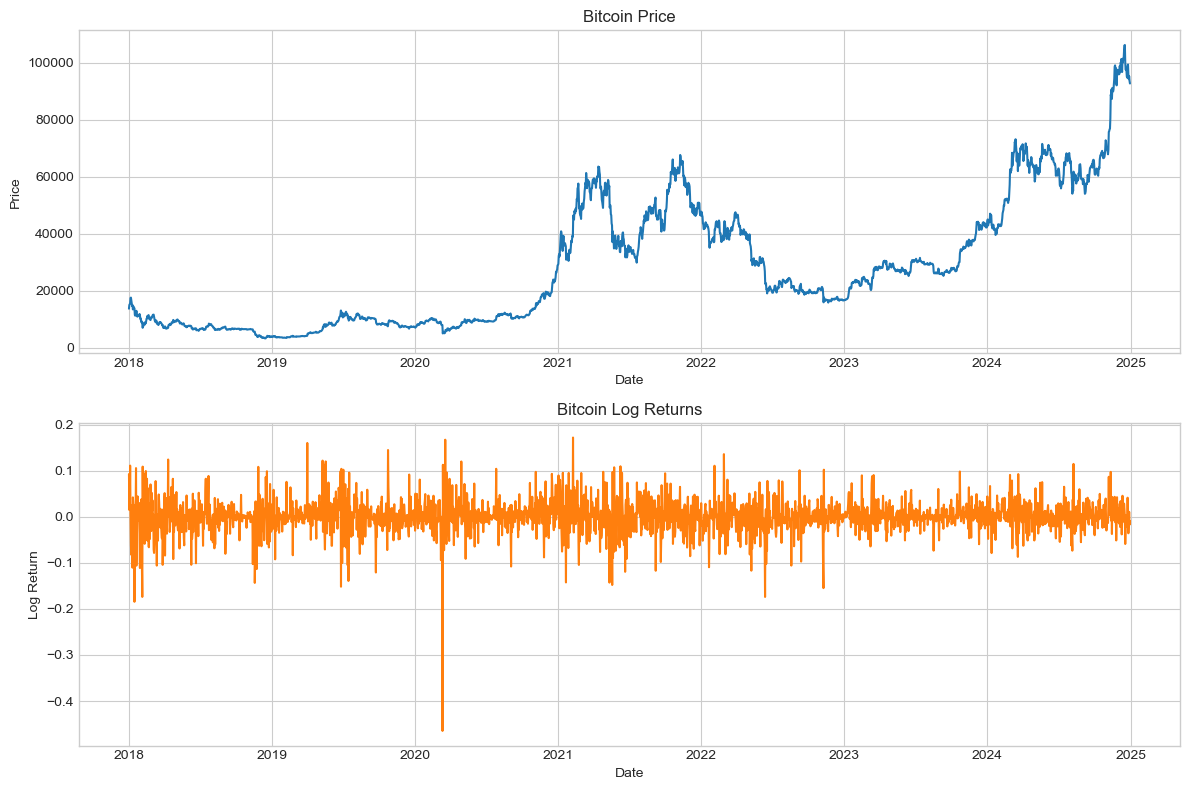

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

axes[0].plot(df['Date'], df['Price'], color='tab:blue')
axes[0].set_title('Bitcoin Price')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price')

axes[1].plot(df.loc[df['Return'].notna(), 'Date'], returns, color='tab:orange')
axes[1].set_title('Bitcoin Log Returns')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Log Return')

plt.tight_layout()
plt.show()

In [6]:
def sample_acf(series, max_lag):
    series = pd.Series(series).dropna().reset_index(drop=True)
    acf_values = [1.0]
    for lag in range(1, max_lag + 1):
        acf_values.append(series.autocorr(lag=lag))
    return pd.Series(acf_values, index=range(0, max_lag + 1), name='ACF')

max_lag = 20
acf_values = sample_acf(returns, max_lag)
acf_table = acf_values.to_frame()
acf_table.index.name = 'Lag'
acf_table

,ACF
Lag,
0,1.000000
1,-0.045227
2,0.047891
3,0.006808
4,0.028383
5,0.016939
6,0.021079
7,-0.023294
8,-0.026504


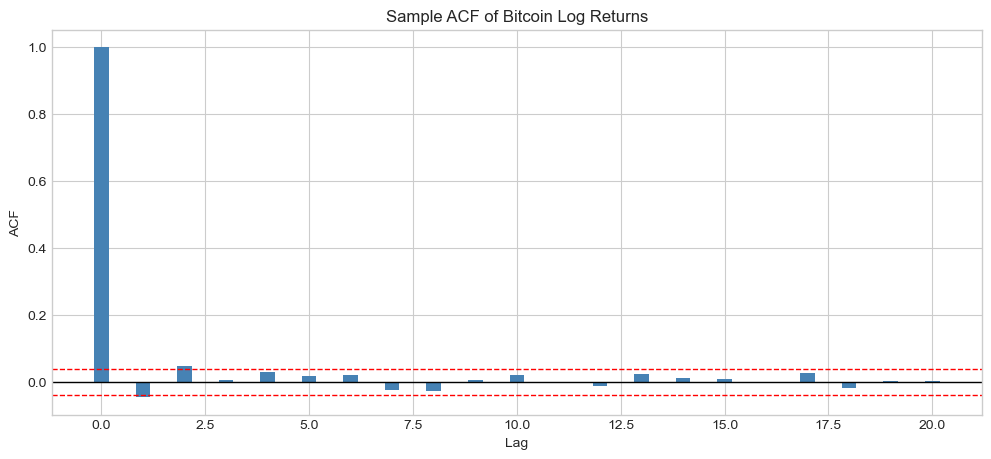

In [7]:
conf_band = 1.96 / np.sqrt(len(returns))

fig, ax = plt.subplots(figsize=(12, 5))
ax.axhline(0, color='black', linewidth=1)
ax.axhline(conf_band, color='red', linestyle='--', linewidth=1)
ax.axhline(-conf_band, color='red', linestyle='--', linewidth=1)
ax.bar(acf_values.index, acf_values.values, width=0.35, color='steelblue')
ax.set_title('Sample ACF of Bitcoin Log Returns')
ax.set_xlabel('Lag')
ax.set_ylabel('ACF')
plt.show()

In [8]:
significant_lags = acf_table.iloc[1:].copy()
significant_lags['Abs ACF'] = significant_lags['ACF'].abs()
significant_lags['Outside 95% Band'] = significant_lags['Abs ACF'] > conf_band
significant_lags

,ACF,Abs ACF,Outside 95% Band
Lag,,,
1,-0.045227,0.045227,True
2,0.047891,0.047891,True
3,0.006808,0.006808,False
4,0.028383,0.028383,False
5,0.016939,0.016939,False
6,0.021079,0.021079,False
7,-0.023294,0.023294,False
8,-0.026504,0.026504,False
9,0.004517,0.004517,False


### Conclusion

Based on the computed Bitcoin log returns, the sample autocorrelations at lag 1 and lag 2 are \(-0.0452\) and \(0.0479\), and both are outside the 95% confidence band. From lag 3 onward, all reported autocorrelations lie inside the confidence band and are close to zero.

Therefore, the sample ACF shows a cutoff after lag 2, which is consistent with the theoretical behavior of an MA(2) process. Hence, the Bitcoin returns in this dataset can be reasonably modeled by a finite-order MA(\(q\)) model, and the empirical evidence here most strongly supports an MA(2) specification.

## Question 2: AR($p$) Model for Bitcoin Returns

For an AR(2) process,

$$
X_t = c + b_1 X_{t-1} + b_2 X_{t-2} + \varepsilon_t,
$$

where $\{\varepsilon_t\}$ is white noise with

$$
E(\varepsilon_t)=0, \qquad \operatorname{Var}(\varepsilon_t)=\sigma^2.
$$

More generally, an AR($p$) process is

$$
X_t = c + b_1 X_{t-1} + \cdots + b_p X_{t-p} + \varepsilon_t.
$$

A key property is that the PACF cuts off after lag $p$, while the ACF usually decays gradually. The code below computes sample PACF-style estimates and compares several AR($p$) models for Bitcoin log returns.

In [9]:
def sample_pacf(series, max_lag):
    series = pd.Series(series).dropna().reset_index(drop=True)
    pacf_values = [1.0]

    for lag in range(1, max_lag + 1):
        y = series.iloc[lag:].to_numpy()
        X = np.column_stack([series.iloc[lag - j:-j].to_numpy() for j in range(1, lag + 1)])
        X = np.column_stack([np.ones(len(X)), X])
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        pacf_values.append(beta[-1])

    return pd.Series(pacf_values, index=range(0, max_lag + 1), name='PACF')


def fit_ar_ols(series, p):
    series = pd.Series(series).dropna().reset_index(drop=True)
    y = series.iloc[p:].to_numpy()
    X = np.column_stack([series.iloc[p - j:-j].to_numpy() for j in range(1, p + 1)])
    X = np.column_stack([np.ones(len(X)), X])

    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    fitted = X @ beta
    resid = y - fitted

    n = len(y)
    k = p + 1
    rss = np.sum(resid ** 2)
    sigma2 = rss / n
    aic = n * np.log(sigma2) + 2 * k
    bic = n * np.log(sigma2) + k * np.log(n)

    return {
        'order': p,
        'intercept': beta[0],
        'coefficients': beta[1:],
        'residuals': pd.Series(resid),
        'rss': rss,
        'sigma2': sigma2,
        'aic': aic,
        'bic': bic
    }

For an AR($p$) model, the partial autocorrelation function should become negligible after lag $p$. This makes the PACF a useful diagnostic when checking whether Bitcoin returns may follow a finite-order AR model.

In [10]:
max_lag_pacf = 20
pacf_values = sample_pacf(returns, max_lag_pacf)
pacf_table = pacf_values.to_frame()
pacf_table.index.name = 'Lag'
pacf_table

,PACF
Lag,
0,1.000000
1,-0.045169
2,0.045859
3,0.010981
4,0.026913
5,0.018758
6,0.020136
7,-0.023642
8,-0.031942


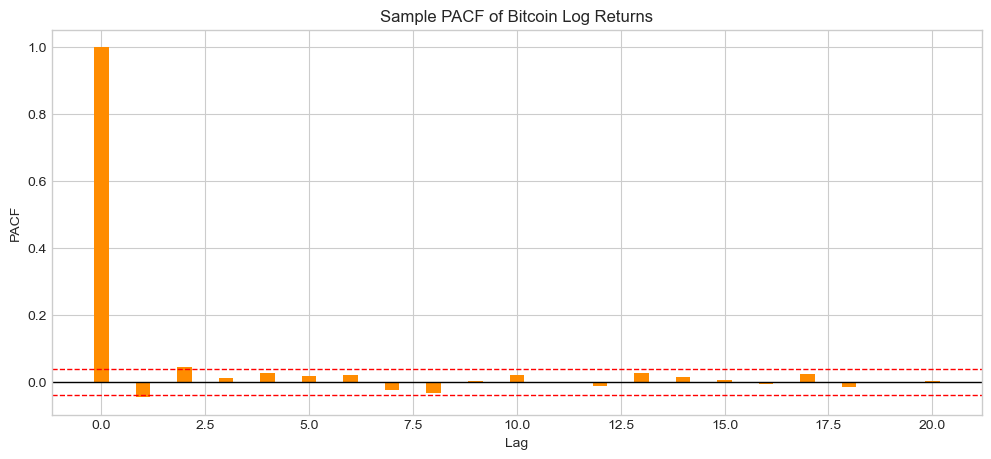

In [11]:
pacf_conf_band = 1.96 / np.sqrt(len(returns))

fig, ax = plt.subplots(figsize=(12, 5))
ax.axhline(0, color='black', linewidth=1)
ax.axhline(pacf_conf_band, color='red', linestyle='--', linewidth=1)
ax.axhline(-pacf_conf_band, color='red', linestyle='--', linewidth=1)
ax.bar(pacf_values.index, pacf_values.values, width=0.35, color='darkorange')
ax.set_title('Sample PACF of Bitcoin Log Returns')
ax.set_xlabel('Lag')
ax.set_ylabel('PACF')
plt.show()

In [12]:
significant_pacf_lags = pacf_table.iloc[1:].copy()
significant_pacf_lags['Abs PACF'] = significant_pacf_lags['PACF'].abs()
significant_pacf_lags['Outside 95% Band'] = significant_pacf_lags['Abs PACF'] > pacf_conf_band
significant_pacf_lags

,PACF,Abs PACF,Outside 95% Band
Lag,,,
1,-0.045169,0.045169,True
2,0.045859,0.045859,True
3,0.010981,0.010981,False
4,0.026913,0.026913,False
5,0.018758,0.018758,False
6,0.020136,0.020136,False
7,-0.023642,0.023642,False
8,-0.031942,0.031942,False
9,0.002377,0.002377,False


In [13]:
ar_results = []

for p in range(1, 6):
    result = fit_ar_ols(returns, p)
    ar_results.append({
        'p': p,
        'Intercept': result['intercept'],
        'AIC': result['aic'],
        'BIC': result['bic'],
        'Sigma^2': result['sigma2']
    })

ar_comparison = pd.DataFrame(ar_results)
ar_comparison

,p,Intercept,AIC,BIC,Sigma^2
0,1,0.000747,-17034.621614,-17022.930782,0.001267
1,2,0.000704,-17030.593737,-17013.058664,0.001264
2,3,0.000688,-17021.597304,-16998.218773,0.001265
3,4,0.000628,-17023.349563,-16994.128360,0.001259
4,5,0.000612,-17014.606212,-16979.543120,0.001259


In [14]:
best_p = int(ar_comparison.sort_values('BIC').iloc[0]['p'])
best_ar = fit_ar_ols(returns, best_p)

coef_table = pd.DataFrame({
    'Term': ['Intercept'] + [f'Lag {i}' for i in range(1, best_p + 1)],
    'Estimate': [best_ar['intercept']] + list(best_ar['coefficients'])
})
coef_table

,Term,Estimate
0,Intercept,0.000747
1,Lag 1,-0.045169


In [15]:
resid_acf = sample_acf(best_ar['residuals'], 20).to_frame(name='Residual ACF')
resid_acf.index.name = 'Lag'
resid_acf

,Residual ACF
Lag,
0,1.000000
1,0.001568
2,0.045680
3,0.007151
4,0.029331
5,0.021050
6,0.023391
7,-0.022439
8,-0.028165


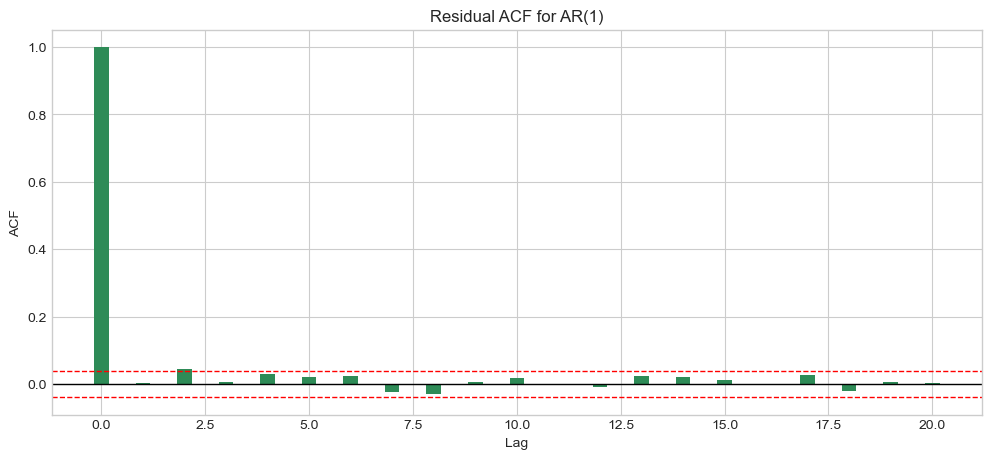

In [16]:
resid_conf_band = 1.96 / np.sqrt(len(best_ar['residuals']))

fig, ax = plt.subplots(figsize=(12, 5))
ax.axhline(0, color='black', linewidth=1)
ax.axhline(resid_conf_band, color='red', linestyle='--', linewidth=1)
ax.axhline(-resid_conf_band, color='red', linestyle='--', linewidth=1)
ax.bar(resid_acf.index, resid_acf['Residual ACF'], width=0.35, color='seagreen')
ax.set_title(f'Residual ACF for AR({best_p})')
ax.set_xlabel('Lag')
ax.set_ylabel('ACF')
plt.show()

### Conclusion

Based on the computed Bitcoin log returns, the sample PACF is outside the 95% confidence band at lag 1 and lag 2, while the higher-lag PACF values are small and remain inside the confidence band. This pattern is compatible with a low-order AR model.

Among the fitted models AR(1) to AR(5), the BIC is smallest for AR(1), so AR(1) is the preferred specification in this comparison. In addition, the residual ACF of the fitted AR(1) model is close to zero at the reported lags, which suggests that the remaining serial dependence is weak. Therefore, the Bitcoin returns in this dataset can be reasonably modeled by an AR(\(p\)) process, and the empirical results here support AR(1) most strongly.